# Notebook 03 — Date-Proximity Temporal Linkage Analysis

## Human-to-Gorilla Zoonotic Disease Transmission Risk Analysis

---

### Purpose
This is the **methodological core** of the project. We link gorilla illness events to
preceding tourist respiratory illness events using:

1. **Temporal window**: 2–14 days (respiratory incubation period, CDC)
2. **Spatial control**: Same gorilla group (location-matched)
3. **Confidence scoring**: Number of symptomatic visitors + severity + time lag
4. **SQL-based range join**: Efficient in-memory SQLite linkage
5. **Sensitivity analysis**: Test attribution stability across window sizes

### Methodological Note (Limitation)
> **Confounding challenge**: We cannot perfectly distinguish human-sourced from gorilla-to-gorilla
> transmission without pathogen genomic sequencing. The confidence score is a probabilistic
> framework, not a causal proof. This is explicitly acknowledged in Grützmacher et al. (2018).

## Cell 1 — Imports

In [11]:
import sys
import sqlite3
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.linkage import TemporalLinkage
from src.viz_utils import set_style, save_fig, plot_attribution_summary, PALETTE

set_style()

RAW_DIR  = PROJECT_ROOT / 'data' / 'raw'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR  = PROJECT_ROOT / 'outputs' / 'figures'

print('Linkage analysis notebook ready.')

Linkage analysis notebook ready.


## Cell 2 — Load Data

In [12]:
tourist_health_df = pd.read_csv(RAW_DIR / 'tourist_health_records.csv', parse_dates=['visit_date'])
gorilla_health_df = pd.read_csv(RAW_DIR / 'gorilla_health_events.csv', parse_dates=['event_date'])
demographics_df   = pd.read_csv(RAW_DIR / 'gorilla_demographics.csv')

print(f'Tourist health records: {len(tourist_health_df):,}')
print(f'Gorilla health events:  {len(gorilla_health_df):,}')
print(f'Gorilla demographics:   {len(demographics_df):,}')

# Symptomatic tourists
sym_tourists = tourist_health_df[tourist_health_df['had_symptoms'] == True].copy()
print(f'\nSymptomatic tourist visits: {len(sym_tourists):,} '
      f'({len(sym_tourists)/len(tourist_health_df)*100:.1f}% of all visits)')

Tourist health records: 65,502
Gorilla health events:  19,836
Gorilla demographics:   105

Symptomatic tourist visits: 4,919 (7.5% of all visits)


## Cell 3 — The Linkage SQL Query (Explained)

In [13]:
# ── Demonstrate the core SQL linkage query ────────────────────────────────────
# This is the same query executed inside TemporalLinkage._sql_linkage()
# but shown here explicitly for transparency and learning.

WINDOW_DAYS = 14   # standard linkage window

conn = sqlite3.connect(':memory:')
gorilla_health_df.to_sql('gorilla_events', conn, index=False, if_exists='replace')
sym_tourists.to_sql('sym_visits', conn, index=False, if_exists='replace')

sql_explain = f"""
/*
   TEMPORAL LINKAGE QUERY — Human-to-Gorilla Disease Transmission
   
   For each gorilla illness event:
     - LEFT JOIN to all symptomatic tourist visits at the SAME GROUP
     - WHERE the tourist visit occurred 0-{WINDOW_DAYS} days BEFORE illness onset
     - Aggregate: count symptomatic visitors, max severity, min lag
     - A gorilla event is 'tourism_proximate' if count > 0
*/
SELECT
    ge.event_id,
    ge.gorilla_id,
    ge.event_date,
    ge.group_id,
    ge.illness_type,
    ge.severity,
    
    -- How many symptomatic tourists visited this group in the preceding {WINDOW_DAYS} days?
    COUNT(sv.tourist_id)   AS n_sym_tourists_in_window,
    
    -- How soon after the tourist visit did illness appear?
    MIN(julianday(ge.event_date) - julianday(sv.visit_date)) AS days_since_earliest_exposure,
    
    -- What was the highest severity tourist symptom in window?
    MAX(CASE sv.symptom_severity
            WHEN 'severe'   THEN 3
            WHEN 'moderate' THEN 2
            WHEN 'mild'     THEN 1
            ELSE 0 END) AS max_severity_score,
    
    -- Binary: was there ANY symptomatic tourist in window?
    CASE WHEN COUNT(sv.tourist_id) > 0 THEN 1 ELSE 0 END AS tourism_proximate

FROM gorilla_events ge
LEFT JOIN sym_visits sv
    -- Spatial control: must be same gorilla group
    ON  ge.group_id = sv.group_visited
    -- Temporal window: tourist visit precedes gorilla illness by 0-{WINDOW_DAYS} days
    AND julianday(ge.event_date) - julianday(sv.visit_date) BETWEEN 0 AND {WINDOW_DAYS}

GROUP BY
    ge.event_id, ge.gorilla_id, ge.event_date, ge.group_id,
    ge.illness_type, ge.severity

ORDER BY ge.event_date
"""

print('Executing linkage SQL...')
raw_linkage = pd.read_sql(sql_explain, conn)
conn.close()

print(f'Total gorilla events: {len(raw_linkage):,}')
print(f'Tourism-proximate:    {raw_linkage["tourism_proximate"].sum():,} '
      f'({raw_linkage["tourism_proximate"].mean()*100:.1f}%)')
print(f'\nSample output:')
print(raw_linkage[raw_linkage['tourism_proximate'] == 1].head(5).to_string(index=False))

Executing linkage SQL...
Total gorilla events: 19,836
Tourism-proximate:    19,223 (96.9%)

Sample output:
 event_id gorilla_id          event_date group_id illness_type severity  n_sym_tourists_in_window  days_since_earliest_exposure  max_severity_score  tourism_proximate
GHE-08215     G-0046 2015-01-02 00:00:00    Pablo  respiratory     mild                         2                           1.0                   1                  1
GHE-16687     G-0085 2015-01-04 00:00:00 Ntambara  respiratory moderate                         2                           2.0                   2                  1
GHE-18103     G-0095 2015-01-05 00:00:00 Ntambara  respiratory     mild                         2                           3.0                   2                  1
GHE-19290     G-0103 2015-01-05 00:00:00  Umubano  respiratory     mild                         2                           1.0                   1                  1
GHE-00540     G-0005 2015-01-06 00:00:00     Susa        o

## Cell 4 — Run Full Linkage Pipeline

In [14]:
# ── Full linkage with confidence scoring ──────────────────────────────────────
linker = TemporalLinkage(window_days=14)

linked_df = linker.link_events(
    tourist_df=tourist_health_df,
    gorilla_df=gorilla_health_df,
    gorilla_demographics=demographics_df,
)

print('=== FULL LINKAGE RESULTS ===')
print(f'Total gorilla events analysed: {len(linked_df):,}')
print(f'Tourism-proximate events:      {linked_df["tourism_proximate"].sum():,}')

print(f'\nAttribution breakdown:')
if 'attributed_source' in linked_df.columns:
    print(linked_df['attributed_source'].value_counts().to_string())

print(f'\nLinkage confidence score distribution:')
if 'linkage_confidence' in linked_df.columns:
    print(linked_df['linkage_confidence'].describe().round(3).to_string())

=== FULL LINKAGE RESULTS ===
Total gorilla events analysed: 19,836
Tourism-proximate events:      19,223

Attribution breakdown:
attributed_source
tourism_attributed    18519
tourism_possible        704
non_tourism             613

Linkage confidence score distribution:
count    19836.000
mean         0.810
std          0.216
min          0.000
25%          0.690
50%          0.870
75%          1.000
max          1.000


## Cell 5 — Attribution by Gorilla Group (SQL)

In [15]:
# ── Group-level attribution summary via SQL ───────────────────────────────────
conn2 = sqlite3.connect(':memory:')
linked_df.to_sql('linked_events', conn2, index=False, if_exists='replace')

group_summary_sql = """
SELECT
    group_id,
    COUNT(*) AS total_events,
    SUM(CASE WHEN attributed_source = 'tourism_attributed' THEN 1 ELSE 0 END) AS tourism_attributed,
    SUM(CASE WHEN attributed_source = 'tourism_possible'   THEN 1 ELSE 0 END) AS tourism_possible,
    SUM(CASE WHEN attributed_source = 'non_tourism'        THEN 1 ELSE 0 END) AS non_tourism,
    ROUND(SUM(CASE WHEN attributed_source = 'tourism_attributed' THEN 1 ELSE 0 END)
          * 100.0 / COUNT(*), 1) AS pct_tourism_attributed,
    ROUND(AVG(linkage_confidence), 3) AS avg_confidence,
    ROUND(AVG(CASE WHEN tourism_proximate = 1 THEN days_since_earliest_exposure END), 1) AS avg_lag_days
FROM linked_events
GROUP BY group_id
ORDER BY pct_tourism_attributed DESC
"""

group_summary = pd.read_sql(group_summary_sql, conn2)
conn2.close()

print('=== ATTRIBUTION BY GORILLA GROUP ===')
print(group_summary.to_string(index=False))

=== ATTRIBUTION BY GORILLA GROUP ===
group_id  total_events  tourism_attributed  tourism_possible  non_tourism  pct_tourism_attributed  avg_confidence  avg_lag_days
   Pablo          4340                4177                89           74                    96.2           0.845           3.1
    Susa          5648                5425               151           72                    96.1           0.854           3.0
  Agasha          3330                3096               137           97                    93.0           0.812           3.2
   Hirwa          2306                2120               114           72                    91.9           0.792           3.5
 Umubano          2126                1883               108          135                    88.6           0.732           3.9
Ntambara          2086                1818               105          163                    87.2           0.718           4.0


## Cell 6 — Sensitivity Analysis (Window Size)

=== SENSITIVITY ANALYSIS: LINKAGE WINDOW SIZE ===
(If % attributed jumps dramatically, the linkage is not stable)

 window_days  total_events  tourism_attributed  tourism_possible  pct_attributed  pct_possible
           5         19836               15022                 0           75.73          0.00
           7         19836               16782                 0           84.60          0.00
          10         19836               17577               679           88.61          3.42
          14         19836               18519               704           93.36          3.55
          21         19836               19365               307           97.63          1.55
  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/03_sensitivity_analysis.png


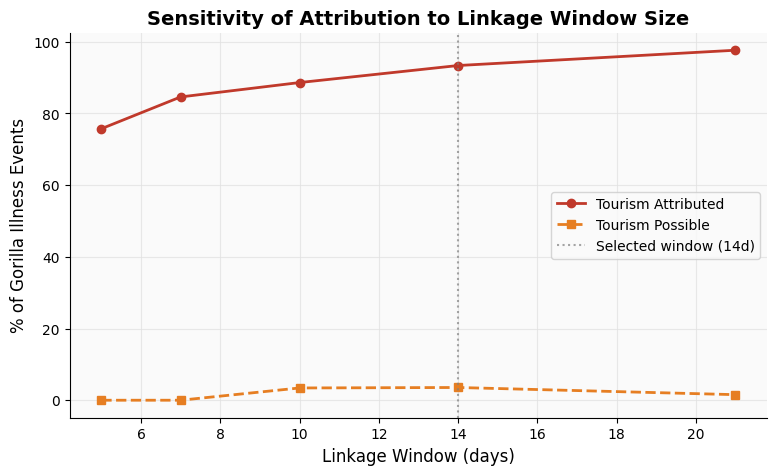

In [16]:
# ── Test stability of results across window sizes ─────────────────────────────
# If attribution rates change wildly with window, results are not robust.
print('=== SENSITIVITY ANALYSIS: LINKAGE WINDOW SIZE ===')
print('(If % attributed jumps dramatically, the linkage is not stable)')
print()

sensitivity = linker.sensitivity_analysis(
    tourist_health_df,
    gorilla_health_df,
    window_range=[5, 7, 10, 14, 21],
)

print(sensitivity.to_string(index=False))

# Plot sensitivity
set_style()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sensitivity['window_days'], sensitivity['pct_attributed'],
        marker='o', color='#C0392B', linewidth=2, label='Tourism Attributed')
ax.plot(sensitivity['window_days'], sensitivity['pct_possible'],
        marker='s', color='#E67E22', linewidth=2, linestyle='--', label='Tourism Possible')
ax.axvline(x=14, color='gray', linestyle=':', alpha=0.7, label='Selected window (14d)')
ax.set_xlabel('Linkage Window (days)')
ax.set_ylabel('% of Gorilla Illness Events')
ax.set_title('Sensitivity of Attribution to Linkage Window Size')
ax.legend()
save_fig(fig, '03_sensitivity_analysis.png', str(FIG_DIR) + '/')
plt.show()

## Cell 7 — Attribution Visualization

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/03_attribution_summary.png


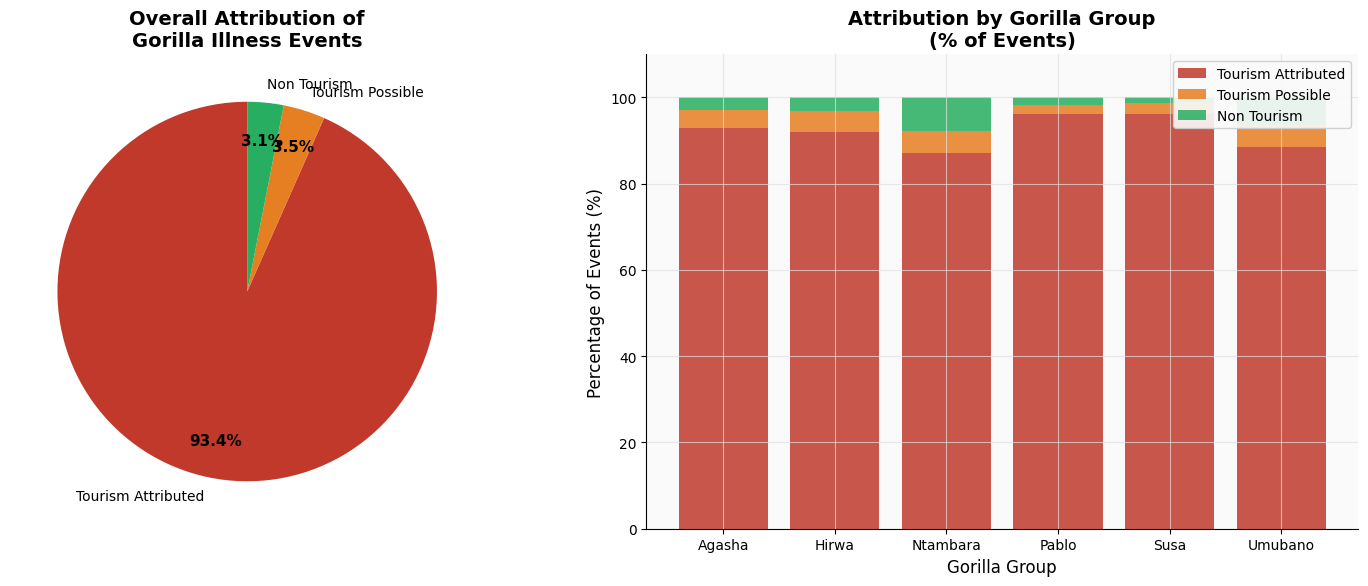

In [17]:
fig, axes = plot_attribution_summary(linked_df, figsize=(15, 6))
save_fig(fig, '03_attribution_summary.png', str(FIG_DIR) + '/')
plt.show()

## Cell 8 — Linkage Timeline: Example Group

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/03_linkage_timeline_Susa_2019.png


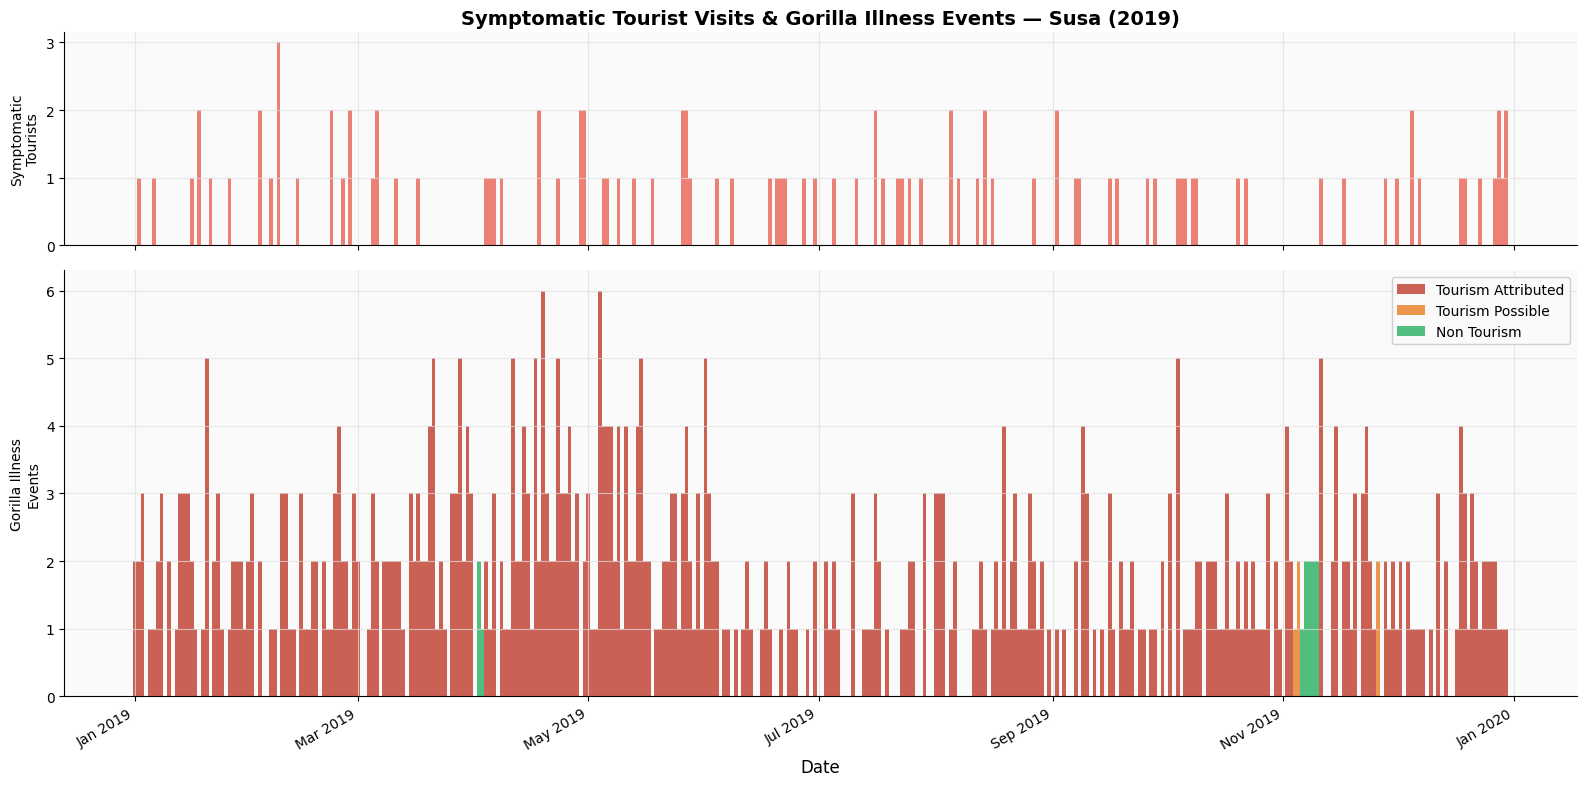

In [18]:
from src.viz_utils import plot_linkage_timeline

# Focus on the highest-visited group for illustration
example_group = 'Susa'

fig, axes = plot_linkage_timeline(
    linked_df=linked_df,
    tourist_df=tourist_health_df,
    group_filter=example_group,
    year_filter=2019,   # Pre-COVID year for clean baseline
    figsize=(16, 8),
)

save_fig(fig, f'03_linkage_timeline_{example_group}_2019.png', str(FIG_DIR) + '/')
plt.show()

## Cell 9 — Confidence Score Distribution

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/03_confidence_distribution.png


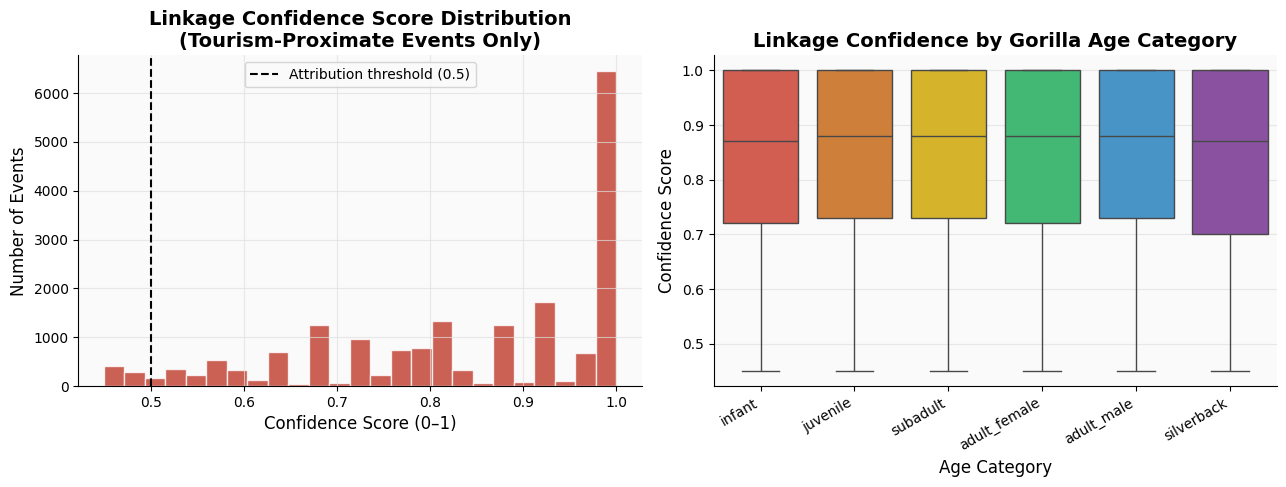

In [19]:
if 'linkage_confidence' in linked_df.columns:
    set_style()
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Histogram of confidence scores
    proximate = linked_df[linked_df['tourism_proximate'] == True]
    axes[0].hist(proximate['linkage_confidence'], bins=25,
                 color='#C0392B', alpha=0.8, edgecolor='white')
    axes[0].axvline(x=0.5, color='black', linestyle='--', label='Attribution threshold (0.5)')
    axes[0].set_title('Linkage Confidence Score Distribution\n(Tourism-Proximate Events Only)')
    axes[0].set_xlabel('Confidence Score (0–1)')
    axes[0].set_ylabel('Number of Events')
    axes[0].legend()

    # Confidence by age category
    if 'age_category' in linked_df.columns:
        age_order = [c for c in ['infant','juvenile','subadult','adult_female','adult_male','silverback']
                     if c in proximate['age_category'].values]
        sns.boxplot(
            data=proximate,
            x='age_category',
            y='linkage_confidence',
            order=age_order,
            ax=axes[1],
            palette=[PALETTE.get(c, '#95A5A6') for c in age_order],
        )
        axes[1].set_xticklabels(age_order, rotation=30, ha='right')
        axes[1].set_title('Linkage Confidence by Gorilla Age Category')
        axes[1].set_xlabel('Age Category')
        axes[1].set_ylabel('Confidence Score')

    plt.tight_layout()
    save_fig(fig, '03_confidence_distribution.png', str(FIG_DIR) + '/')
    plt.show()

## Cell 10 — Save Linked Dataset

In [20]:
# Save linked dataset for downstream notebooks
linked_df.to_csv(PROC_DIR / 'gorilla_health_linked.csv', index=False)
print(f'Saved: {PROC_DIR}/gorilla_health_linked.csv ({len(linked_df):,} rows)')

# Summary statistics
summary_stats = {
    'total_events': len(linked_df),
    'tourism_proximate_events': int(linked_df['tourism_proximate'].sum()),
    'pct_tourism_proximate': round(linked_df['tourism_proximate'].mean() * 100, 2),
    'window_days_used': 14,
}
if 'attributed_source' in linked_df.columns:
    for src, cnt in linked_df['attributed_source'].value_counts().items():
        summary_stats[f'n_{src}'] = int(cnt)
        summary_stats[f'pct_{src}'] = round(cnt / len(linked_df) * 100, 2)

pd.Series(summary_stats).to_csv(PROC_DIR / 'linkage_summary_stats.csv', header=['value'])
print('\n=== LINKAGE SUMMARY ===')
for k, v in summary_stats.items():
    print(f'  {k:<40} {v}')

print('\n✅ Notebook 03 complete. Proceed to 04_statistical_analysis.ipynb')

Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\data\processed/gorilla_health_linked.csv (19,836 rows)

=== LINKAGE SUMMARY ===
  total_events                             19836
  tourism_proximate_events                 19223
  pct_tourism_proximate                    96.91
  window_days_used                         14
  n_tourism_attributed                     18519
  pct_tourism_attributed                   93.36
  n_tourism_possible                       704
  pct_tourism_possible                     3.55
  n_non_tourism                            613
  pct_non_tourism                          3.09

✅ Notebook 03 complete. Proceed to 04_statistical_analysis.ipynb
